# 🩺 Chẩn Đoán Viêm Phổi Từ Ảnh X-quang Ngực (Pneumonia Detection)
> **Sổ tay tổng hợp toàn bộ Pipeline (End-to-End Notebook):**
> 1. Khám phá & Trực quan hóa dữ liệu (EDA & Visualization)
> 2. Tiền xử lý, Margin Crop (Loại bỏ ký tự 'R'/'L' & viền đen) & Augmentation (Preprocessing & Class Weights)
> 3. Xây dựng & Huấn luyện mô hình 2 giai đoạn (VGG16 + Custom CNN Head)
> 4. Trực quan hóa tiến trình huấn luyện (Training Curves: Loss & Accuracy)
> 5. Đánh giá mô hình toàn diện (Confusion Matrix, Precision/Recall/F1, ROC-AUC)
> 6. Giải thích mô hình bằng Grad-CAM (Explainable AI - XAI)
> 7. Phân tích lỗi chi tiết (Error Analysis: False Positives / False Negatives)


## 1. Import Thư Viện & Thiết Lập Cấu Hình


In [1]:
import importlib
import os
import sys
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay

# Đảm bảo import được các module trong src/
project_root = os.path.dirname(os.path.abspath("")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if os.path.exists(os.path.join(project_root, "pneumonia_project")):
    project_root = os.path.join(project_root, "pneumonia_project")

sys.path.append(project_root)

from src.config import (
    DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR,
    MODELS_DIR, OUTPUTS_DIR, IMG_SIZE, BATCH_SIZE, SEED,
    EPOCHS_PHASE1, EPOCHS_PHASE2, FINE_TUNE_AT, CLASS_NAMES
)
from src.data_preprocessing import make_generators, get_class_weights, crop_margin, custom_preprocessing
from src.model import build_combined_model
from src.evaluate import evaluate_on_test, plot_training_history
from src.gradcam import visualize_gradcam, make_gradcam_heatmap, overlay_gradcam

import src.train
import src.data_preprocessing
import src.model
importlib.reload(src.train)
importlib.reload(src.data_preprocessing)
importlib.reload(src.model)
from src.train import run_training
from src.data_preprocessing import crop_margin

print("Project Root:", project_root)
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)


Project Root: d:\pneumonia_project\pneumonia_project
TensorFlow Version: 2.10.0
GPU Available: True


## 2. Khám Phá & Trực Quan Hóa Dữ Liệu (EDA)

Trong bước này, chúng ta sẽ:
- Thống kê số lượng ảnh trong từng tập dữ liệu (`train`, `val`, `test`).
- Kiểm tra sự mất cân bằng giữa các lớp (`NORMAL` vs `PNEUMONIA`).
- Trực quan hóa hình ảnh X-quang mẫu của từng lớp.


=== THỐNG KÊ SỐ LƯỢNG MẪU DỮ LIỆU ===
Split     Class  Count
Train    NORMAL   1341
Train PNEUMONIA   3875
  Val    NORMAL      8
  Val PNEUMONIA      8
 Test    NORMAL    234
 Test PNEUMONIA    390


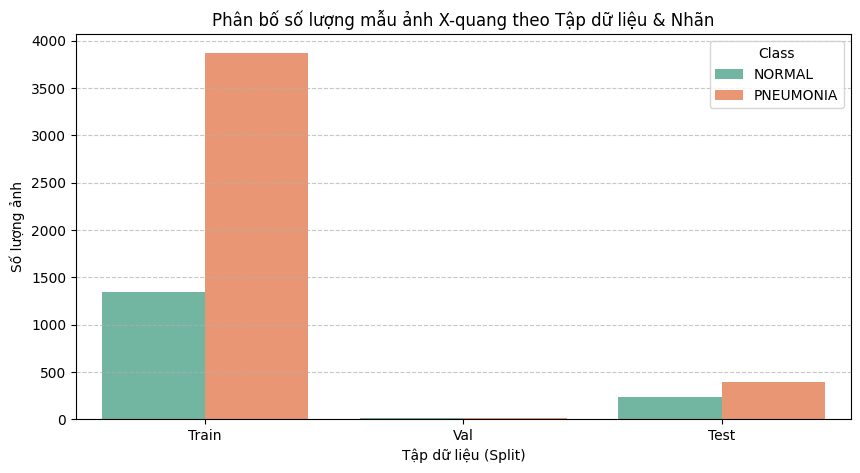

In [2]:
def get_dataset_stats():
    data_counts = []
    for split_name, split_dir in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
        for cls in CLASS_NAMES:
            cls_dir = os.path.join(split_dir, cls)
            if os.path.exists(cls_dir):
                count = len([f for f in os.listdir(cls_dir) if f.lower().endswith(('png', 'jpg', 'jpeg'))])
                data_counts.append({"Split": split_name, "Class": cls, "Count": count})
    return pd.DataFrame(data_counts)

df_stats = get_dataset_stats()
print("=== THỐNG KÊ SỐ LƯỢNG MẪU DỮ LIỆU ===")
print(df_stats.to_string(index=False))

# Biểu đồ cột thể hiện phân bố
plt.figure(figsize=(10, 5))
sns.barplot(data=df_stats, x="Split", y="Count", hue="Class", palette="Set2")
plt.title("Phân bố số lượng mẫu ảnh X-quang theo Tập dữ liệu & Nhãn")
plt.xlabel("Tập dữ liệu (Split)")
plt.ylabel("Số lượng ảnh")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


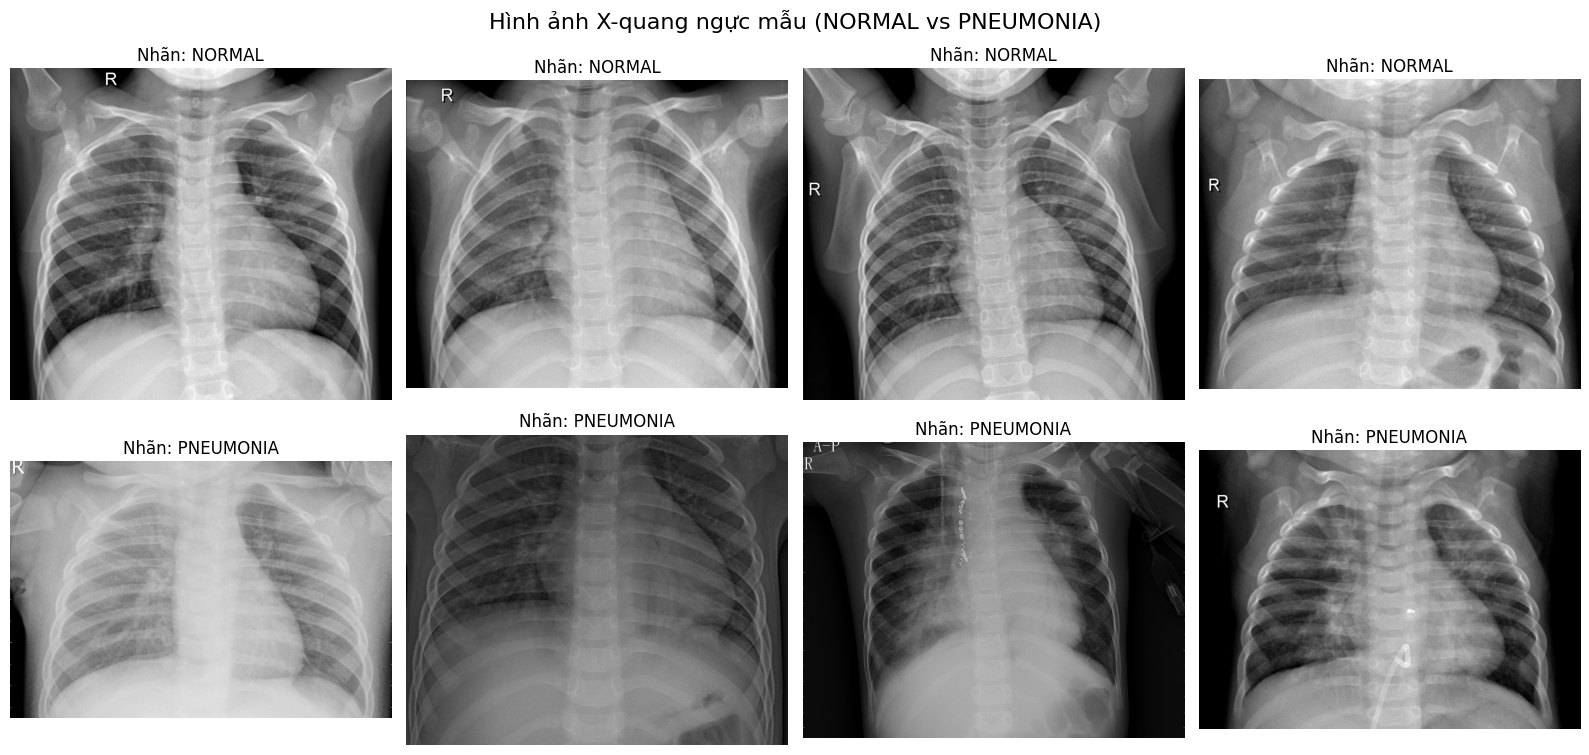

In [3]:
# Hiển thị ảnh mẫu X-quang đại diện của 2 lớp NORMAL và PNEUMONIA
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Hình ảnh X-quang ngực mẫu (NORMAL vs PNEUMONIA)", fontsize=16)

for idx, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    images = [f for f in os.listdir(cls_dir) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    selected_imgs = random.sample(images, 4)
    
    for col, img_name in enumerate(selected_imgs):
        img_path = os.path.join(cls_dir, img_name)
        img = Image.open(img_path)
        ax = axes[idx, col]
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Nhãn: {cls}")
        ax.axis('off')

plt.tight_layout()
plt.show()


## 3. Tiền Xử Lý Dữ Liệu & Loại Bỏ Nhiễu Viền (Margin Crop)

- **Margin Cropping (Cắt 8% viền rìa ảnh):** Loại bỏ triệt để các ký tự chữ `"R"`, `"L"`, dấu mực, đường gạch viền đen/trắng xung quanh lồng ngực để tránh hiện tượng **Shortcut Learning (Overfitting vào viền nhiễu)**.
- **Data Augmentation:** Xoay nhẹ (15°), dịch chuyển (10%), phóng to/thu nhỏ (15%), và lật ngang trên tập Train để tăng tính tổng quát của mô hình.
- **Normalization:** Áp dụng `vgg_preprocess` (chuẩn hóa pixel phù hợp với VGG16 pre-trained).
- **Class Weights:** Tính toán trọng số lớp để xử lý hiện tượng mất cân bằng dữ liệu giữa PNEUMONIA và NORMAL.


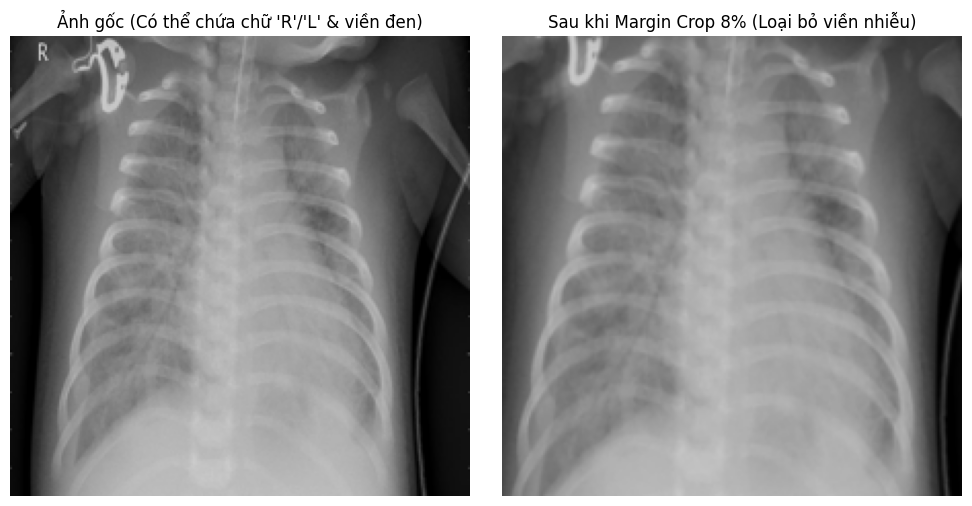

In [4]:
# Minh họa tác dụng của Margin Crop trên 1 ảnh mẫu
pneumonia_sample_dir = os.path.join(TRAIN_DIR, "PNEUMONIA")
sample_files = [f for f in os.listdir(pneumonia_sample_dir) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
sample_img_path = os.path.join(pneumonia_sample_dir, sample_files[0])
img_orig = Image.open(sample_img_path).convert("RGB").resize(IMG_SIZE)
img_arr = np.array(img_orig)

# Áp dụng crop margin 8%
img_cropped = crop_margin(img_arr, crop_percent=0.08)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_arr)
axes[0].set_title("Ảnh gốc (Có thể chứa chữ 'R'/'L' & viền đen)")
axes[0].axis("off")

axes[1].imshow(img_cropped.astype(np.uint8))
axes[1].set_title("Sau khi Margin Crop 8% (Loại bỏ viền nhiễu)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [5]:
# Khởi tạo các ImageDataGenerator cho Train, Val, Test (đã tích hợp custom_preprocessing Margin Crop)
train_gen, val_gen, test_gen = make_generators()

print(f"Số lượng mẫu Train: {train_gen.samples} (Batch size: {BATCH_SIZE})")
print(f"Số lượng mẫu Val  : {val_gen.samples}")
print(f"Số lượng mẫu Test : {test_gen.samples}")

# Tính toán Class Weights
class_weights = get_class_weights(train_gen)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Số lượng mẫu Train: 5216 (Batch size: 16)
Số lượng mẫu Val  : 16
Số lượng mẫu Test : 624
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


## 4. Xây Dựng Kiến Trúc Mô Hình (VGG16 + Custom CNN Head)

Mô hình kết hợp:
1. **Base Model (VGG16):** Trích xuất các đặc trưng ảnh cấp thấp đến cấp cao từ trọng số ImageNet.
2. **Custom CNN Head:** 
   - `Conv2D (256, 3x3)` + `BatchNormalization`
   - `Conv2D (128, 3x3)` + `BatchNormalization` (Target Layer cho Grad-CAM: `custom_conv2`)
   - `MaxPooling2D` + `GlobalAveragePooling2D`
   - `Dropout(0.5)` -> `Dense(256, ReLU)` -> `Dropout(0.3)` -> `Dense(1, Sigmoid)`


In [6]:
# Khởi tạo mô hình ở Giai đoạn 1 (Đóng băng VGG16 base)
model = build_combined_model(freeze_base=True)
model.summary()


Model: "vgg16_custom_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 custom_conv1 (Conv2D)       (None, 7, 7, 256)         1179904   
                                                                 
 batch_normalization (BatchN  (None, 7, 7, 256)        1024      
 ormalization)                                                   
                                                                 
 custom_conv2 (Conv2D)       (None, 7, 7, 128)         295040    
                                                                 
 batch_normalization_1 (Batc  (None, 7, 7, 128)        512       
 hNormalization)                                  

## 5. Huấn Luyện Mô Hình 2 Giai Đoạn (2-Phase Training)

- **Giai đoạn 1 (Phase 1):** Huấn luyện Custom CNN Head ($LR = 10^{-4}$) trong 15 Epochs với VGG16 bị đóng băng.
- **Giai đoạn 2 (Phase 2):** Fine-tune mở khóa các tầng cuối của VGG16 ($LR = 10^{-5}$) trong 15 Epochs.


In [7]:
# Thực thi quy trình huấn luyện 2 giai đoạn đầy đủ
trained_model, history_dict, test_generator = run_training()


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}
=== Huấn luyện mô hình (1 Giai đoạn duy nhất) ===
Model: "vgg16_custom_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 custom_conv1 (Conv2D)       (None, 7, 7, 256)         1179904   
                                                                 
 batch_normalization_2 (Batc  (None, 7, 7, 256)        1024      
 hNormalization)                                                 
                                  

## 6. Trực Quan Hóa Tiến Trình Huấn Luyện (Training Curves)

Vẽ biểu đồ diễn biến **Loss** và **Accuracy** trên tập Train và Val qua toàn bộ các Epochs của 2 giai đoạn.


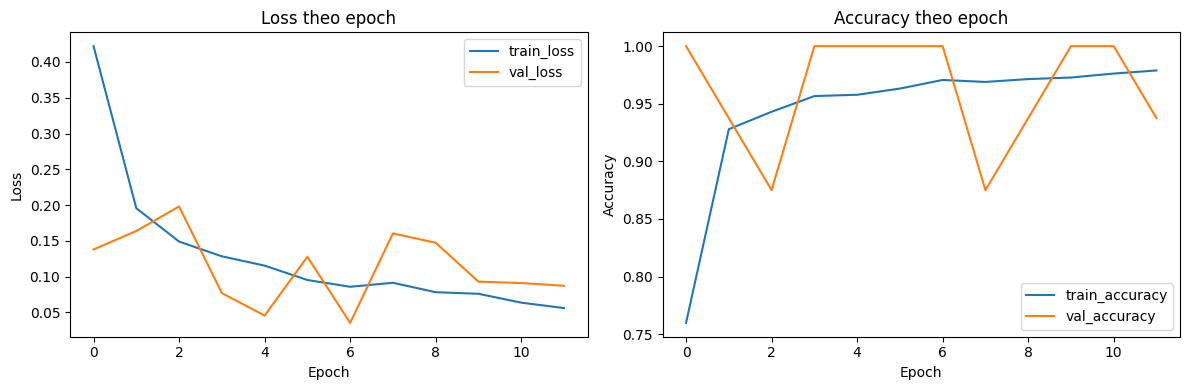

In [8]:
# Vẽ biểu đồ Loss & Accuracy
plot_training_history(history_dict, save_path=os.path.join(MODELS_DIR, "training_curves.png"))


## 7. Đánh Giá Mô Hình Toàn Diện Trên Tập Test

Đánh giá các chỉ số cốt lõi:
- **Ma trận nhầm lẫn (Confusion Matrix)**
- **Báo cáo phân loại (Precision, Recall, F1-Score)**
- **Đường cong ROC và chỉ số AUC Score**


39/39 [==============================] - 9s 216ms/step
              precision    recall  f1-score   support

      NORMAL       0.98      0.86      0.92       234
   PNEUMONIA       0.92      0.99      0.95       390

    accuracy                           0.94       624
   macro avg       0.95      0.93      0.94       624
weighted avg       0.94      0.94      0.94       624



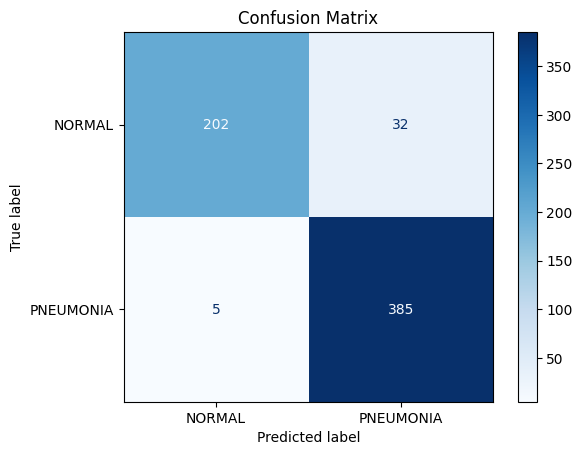

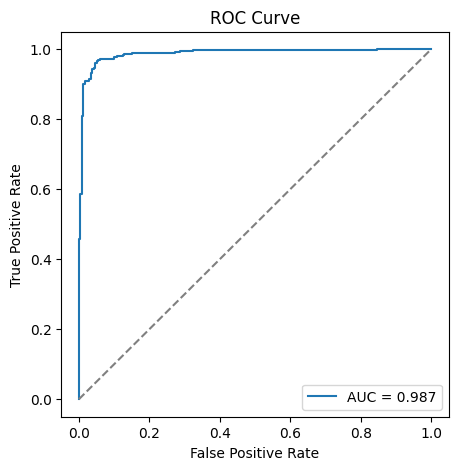

AUC: 0.9871


In [9]:
# Đánh giá trên tập test độc lập
eval_results = evaluate_on_test(trained_model, test_generator, save_dir=OUTPUTS_DIR)


## 8. Trực Quan Hóa Grad-CAM (Explainable AI - XAI)

Sử dụng Grad-CAM để hiển thị vùng mà mô hình "chú ý" (Heatmap) khi chẩn đoán bệnh viêm phổi trên các ảnh X-quang ngẫu nhiên.



--- Trực quan hóa Grad-CAM cho ảnh: person1669_virus_2885.jpeg ---


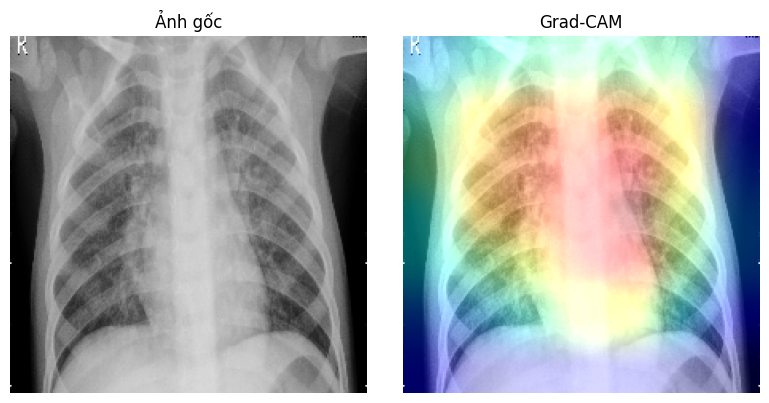


--- Trực quan hóa Grad-CAM cho ảnh: person159_bacteria_747.jpeg ---


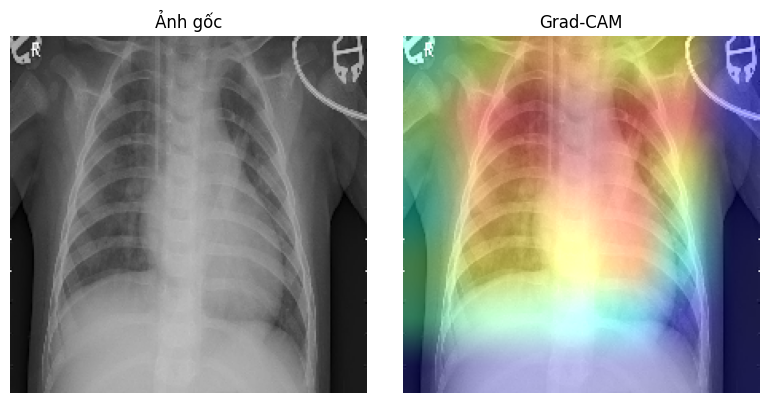


--- Trực quan hóa Grad-CAM cho ảnh: person1649_virus_2850.jpeg ---


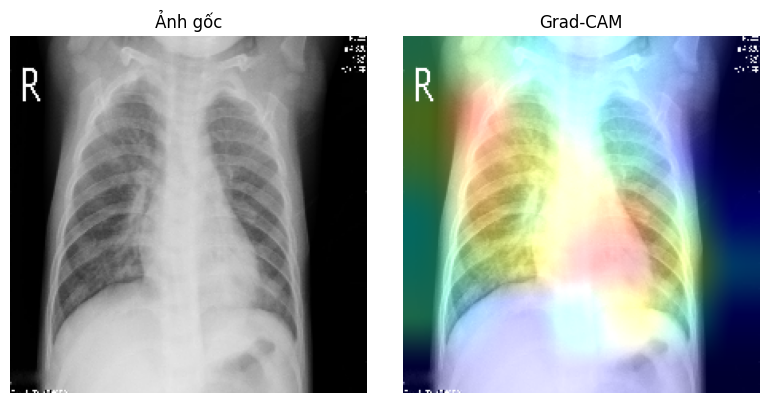

In [10]:
# Trích xuất 3 ảnh PNEUMONIA ngẫu nhiên từ tập Test và hiển thị Grad-CAM
pneumonia_test_dir = os.path.join(TEST_DIR, "PNEUMONIA")
test_images = [f for f in os.listdir(pneumonia_test_dir) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
sample_images = random.sample(test_images, 3)

for img_name in sample_images:
    img_path = os.path.join(pneumonia_test_dir, img_name)
    print(f"\n--- Trực quan hóa Grad-CAM cho ảnh: {img_name} ---")
    visualize_gradcam(img_path, trained_model, last_conv_layer_name="custom_conv2")


## 9. Phân Tích Lỗi Chi Tiết (Error Analysis)

Trích xuất các trường hợp dự đoán sai (**False Positives**: Normal nhưng đoán Pneumonia, **False Negatives**: Pneumonia nhưng đoán Normal) để phân tích nguyên nhân.


Tổng số trường hợp dự đoán sai trên tập test: 37 / 624


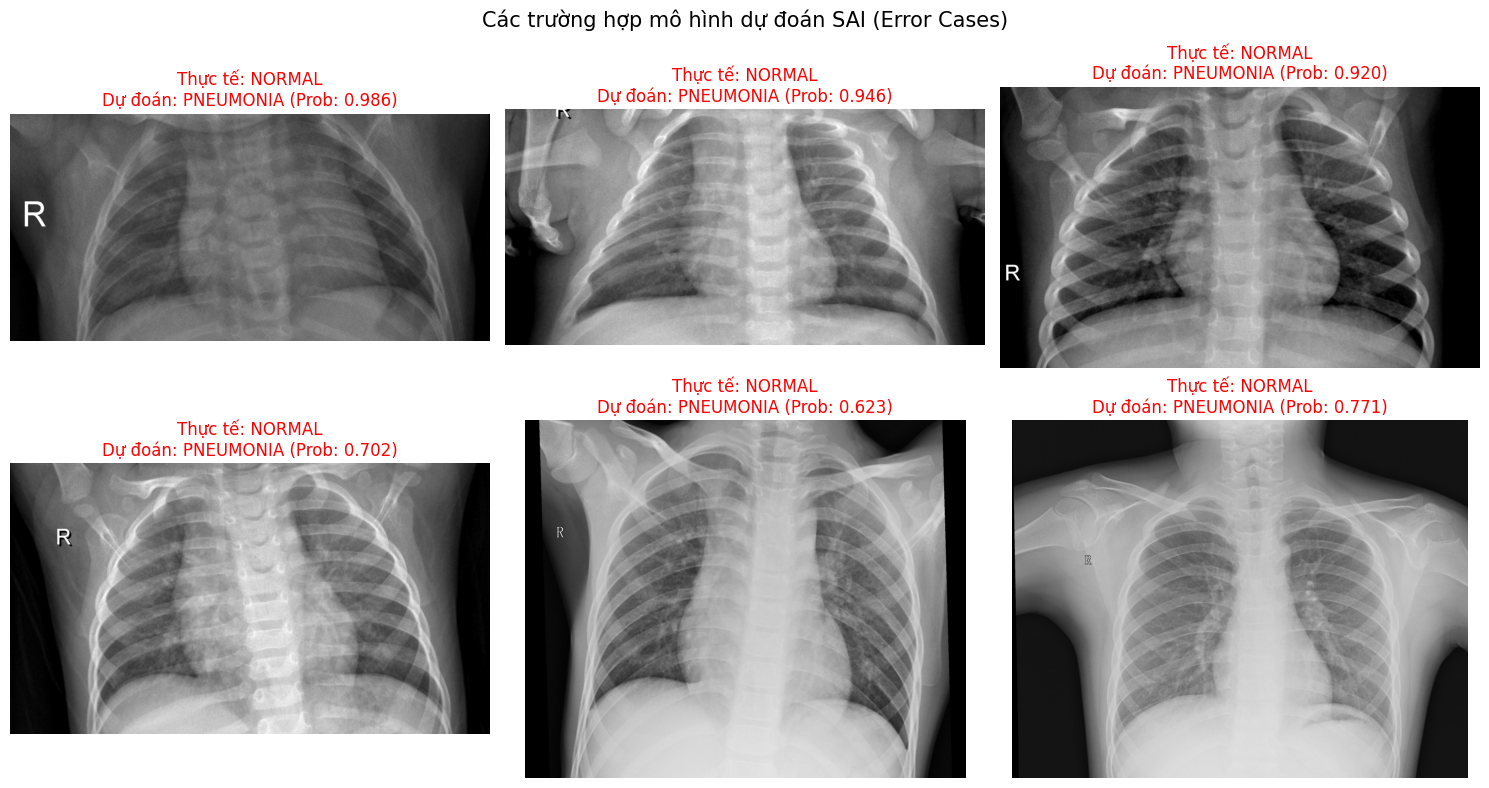

In [11]:
y_true = eval_results["y_true"]
y_prob = eval_results["y_prob"]
y_pred = eval_results["y_pred"]

filenames = test_generator.filenames
errors_idx = np.where(y_pred != y_true)[0]

print(f"Tổng số trường hợp dự đoán sai trên tập test: {len(errors_idx)} / {len(y_true)}")

# Hiển thị tối đa 6 mẫu bị dự đoán sai
num_show = min(6, len(errors_idx))
if num_show > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Các trường hợp mô hình dự đoán SAI (Error Cases)", fontsize=15)
    
    for idx, err_i in enumerate(errors_idx[:num_show]):
        ax = axes[idx // 3, idx % 3]
        img_rel_path = filenames[err_i]
        full_img_path = os.path.join(TEST_DIR, img_rel_path)
        
        img = Image.open(full_img_path)
        true_label = CLASS_NAMES[y_true[err_i]]
        pred_label = CLASS_NAMES[y_pred[err_i]]
        prob = y_prob[err_i]
        
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Thực tế: {true_label}\nDự đoán: {pred_label} (Prob: {prob:.3f})", color="red")
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("Mô hình không đưa ra dự đoán sai nào!")
